\# IBM HR Employee Attrition — Notebook 5: Policy Simulation

\#\# Goal

We now have:

\- A validated set of attrition drivers \(Notebook 3\)
\- A trained logistic regression model that quantifies their effects \(Notebook 4\)

This notebook uses both to answer the central business question:

\> \*\*What policy interventions would reduce attrition, and at what cost?\*\*

We test three intervention types:

1\. \*\*Overtime reduction\*\* — at 25%, 50%, 75%, and 100% levels
2\. \*\*L1 promotion acceleration\*\* — moving entry\-level employees to
   Level 2 in 1 or 2 years instead of the current ~3 years
3\. \*\*Combined OT reduction \+ L1 promotion\*\* — applying both at once

For each scenario we project: new attrition rate, employees retained,
retention savings, intervention cost, and net financial savings\.

This mirrors \*\*Section 6\*\* of the methodology report\.

\#\# A note on what these projections are

These are \*\*directional estimates\*\*, not precise forecasts\. The model
predicts a direction \(intervention X reduces attrition by ~Y%\) and a
magnitude \(~Y is in the 5\-30% range, not 0\.5% or 50%\)\. The exact
percentage point numbers should be read as one of multiple possible
outcomes within a confidence band, not as guaranteed savings\.

The methodology Section 5\.7 documents why: probabilities from the
SMOTE\-trained model are inflated \(mean ~0\.39 vs true rate 0\.133\), so
we use \*\*relative reductions\*\* between scenarios rather than the
model's raw predictions\. This anchors all projections to the observed
16\.12% baseline rate\.

In [1]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# We retrain the model from scratch in this notebook so it can run
# standalone without depending on Notebook 4's kernel state.
# The training code is identical to Notebook 4 — see the comments there
# for the rationale on each choice (SMOTE, threshold, etc.)

\#\# Setup — Recreate the Model from Notebook 4

The next four cells are the abridged version of Notebook 4: build
features, split, scale, SMOTE\-balance, train\. Everything from here
needs the trained \`sim\_model\`, the fitted \`scaler\`, and the original
\`df\` to run policy simulations\.

In [3]:
# Same data prep as Notebook 4

df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime']       = (df['OverTime']  == 'Yes').astype(int)

features = [
    'JobLevel',
    'YearsInCurrentRole',
    'OverTime',
    'JobInvolvement',
    'RelationshipSatisfaction'
]

X = df[features]
y = df['Attrition_Flag']

In [5]:
# Same train/test split as Notebook 4 — fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale on training only — prevents data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# Manual SMOTE — same function as Notebook 4
def manual_smote(X_train, y_train, random_state=42):
    """Synthetically balance binary classes by interpolating between minority samples."""
    rng = np.random.RandomState(random_state)
    X_minority = X_train[y_train == 1]
    X_majority = X_train[y_train == 0]
    n_to_generate = len(X_majority) - len(X_minority)

    synthetic = []
    for _ in range(n_to_generate):
        idx        = rng.randint(0, len(X_minority))
        sample     = X_minority[idx]
        nbr_idx    = rng.randint(0, len(X_minority))
        neighbor   = X_minority[nbr_idx]
        gap        = rng.random()
        new_sample = sample + gap * (neighbor - sample)
        synthetic.append(new_sample)

    X_balanced = np.vstack([X_majority, X_minority, np.array(synthetic)])
    y_balanced = np.hstack([
        np.zeros(len(X_majority)),
        np.ones(len(X_minority)),
        np.ones(n_to_generate)
    ])
    shuffle_idx = rng.permutation(len(X_balanced))
    return X_balanced[shuffle_idx], y_balanced[shuffle_idx]


# Apply SMOTE to training data only
X_train_sm, y_train_sm = manual_smote(X_train_scaled, y_train.values)

print(f"Setup complete.")
print(f"  Training rows after SMOTE: {X_train_sm.shape[0]}")
print(f"  Test rows: {X_test.shape[0]}")

Setup complete.
  Training rows after SMOTE: 1956
  Test rows: 294


In [9]:
# Train the policy simulation model
# This is THE model — sim_model — used by every scenario below

sim_model = LogisticRegression(max_iter=1000, random_state=42)
sim_model.fit(X_train_sm, y_train_sm)

print("sim_model trained.")
print(f"  Trained on {X_train_sm.shape[0]} rows (post-SMOTE)")
print(f"  Variables: {features}")

sim_model trained.
  Trained on 1956 rows (post-SMOTE)
  Variables: ['JobLevel', 'YearsInCurrentRole', 'OverTime', 'JobInvolvement', 'RelationshipSatisfaction']


\#\# Section 6\.1 — Estimating the L1 → L2 Promotion Timeline

Before we can simulate "accelerate L1 to L2 promotion," we need to know
the current L1 → L2 timeline\. The dataset is a point\-in\-time snapshot
with no promotion history — we have to estimate\.

We use three population\-level proxies:

\| Proxy \| What it measures \| Limitation \|
\|\-\-\-\|\-\-\-\|\-\-\-\|
\| \*\*YearsSinceLastPromotion \(median for L2 employees\)\*\* \| If an L2 employee's last promotion was the L1→L2 transition, this gives the time\-to\-promote \| Their last promotion might not have been L1→L2 \|
\| \*\*TotalWorkingYears gap \(L2 median \- L1 median\)\*\* \| Career experience difference between current L1 and L2 employees \| Reflects external hires too, not just internal promotions \|
\| \*\*YearsAtCompany gap \(L2 median \- L1 median\)\*\* \| Tenure difference at THIS company between L1 and L2 \| Most direct proxy for internal time\-to\-promote \|

We average the three to get a synthesized estimate\.

In [11]:
# Three proxies for the L1→L2 promotion timeline

# Proxy 1: Median YearsSinceLastPromotion for current L2 employees
proxy_1 = df[df['JobLevel'] == 2]['YearsSinceLastPromotion'].median()

# Proxy 2a: TotalWorkingYears gap between L1 and L2 medians
proxy_2a = (df[df['JobLevel'] == 2]['TotalWorkingYears'].median() -
            df[df['JobLevel'] == 1]['TotalWorkingYears'].median())

# Proxy 2b: YearsAtCompany gap between L1 and L2 medians
proxy_2b = (df[df['JobLevel'] == 2]['YearsAtCompany'].median() -
            df[df['JobLevel'] == 1]['YearsAtCompany'].median())

# Synthesized estimate — average of the three
proxy_estimate = (proxy_1 + proxy_2a + proxy_2b) / 3

print("── L1 → L2 Promotion Timeline Estimates ──\n")
print(f"Proxy 1: YearsSinceLastPromotion (median for L2)  = {proxy_1:.1f} years")
print(f"Proxy 2a: TotalWorkingYears gap (L2 - L1 median)  = {proxy_2a:.1f} years")
print(f"Proxy 2b: YearsAtCompany gap (L2 - L1 median)     = {proxy_2b:.1f} years")
print(f"\nSynthesized estimate (average):                   = {proxy_estimate:.1f} years")
print(f"\nUsed as baseline assumption: ~3 years current L1→L2 timeline.")

── L1 → L2 Promotion Timeline Estimates ──

Proxy 1: YearsSinceLastPromotion (median for L2)  = 1.0 years
Proxy 2a: TotalWorkingYears gap (L2 - L1 median)  = 4.0 years
Proxy 2b: YearsAtCompany gap (L2 - L1 median)     = 3.0 years

Synthesized estimate (average):                   = 2.7 years

Used as baseline assumption: ~3 years current L1→L2 timeline.


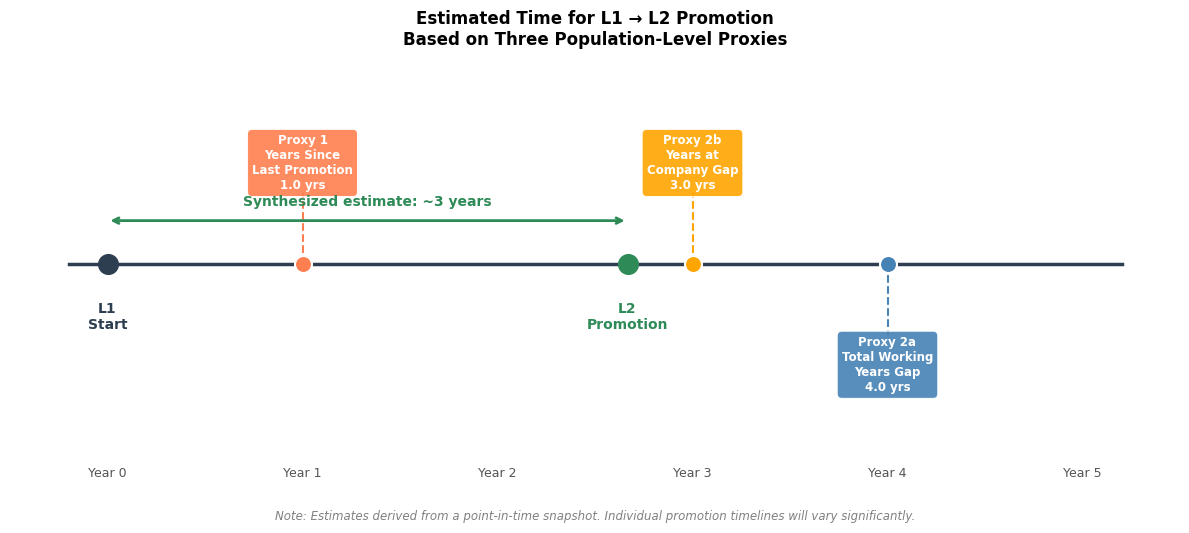

In [13]:
# Three-proxy timeline chart — visualizes how the proxies converge

fig, ax = plt.subplots(figsize=(12, 5))

# ── Timeline base line ───────────────────────────────────────
ax.axhline(y=0, xmin=0.05, xmax=0.95,
           color='#2c3e50', linewidth=2.5, zorder=1)
                # horizontal line representing time
                # zorder=1 puts it behind the markers

# ── Start and end markers ────────────────────────────────────
ax.scatter([0], [0], s=200, color='#2c3e50', zorder=3)
ax.scatter([proxy_estimate], [0], s=200, color='seagreen', zorder=3)

ax.text(0, -0.18, 'L1\nStart', ha='center', fontsize=10,
        fontweight='bold', color='#2c3e50')
ax.text(proxy_estimate, -0.18, 'L2\nPromotion', ha='center', fontsize=10,
        fontweight='bold', color='seagreen')

# ── Three proxy markers ──────────────────────────────────────
proxies = [
    (proxy_1,  f'Proxy 1\nYears Since\nLast Promotion\n{proxy_1:.1f} yrs',  'coral',     0.28),
    (proxy_2a, f'Proxy 2a\nTotal Working\nYears Gap\n{proxy_2a:.1f} yrs',   'steelblue', -0.28),
    (proxy_2b, f'Proxy 2b\nYears at\nCompany Gap\n{proxy_2b:.1f} yrs',      'orange',     0.28),
]
                # each tuple: x position, label, color, y offset
                # y offset alternates above/below so labels don't overlap

for x, label, color, y_offset in proxies:
    # Vertical connector line from timeline to label
    ax.plot([x, x], [0, y_offset * 0.7],
            color=color, linewidth=1.5, linestyle='--', zorder=2)

    # Marker on the timeline
    ax.scatter([x], [0], s=150, color=color, zorder=4,
               edgecolors='white', linewidth=1.5)

    # Label box
    ax.text(x, y_offset, label,
            ha='center', va='center', fontsize=8.5,
            color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor=color, edgecolor='white', alpha=0.9))

# ── Synthesized estimate bracket ─────────────────────────────
ax.annotate('', xy=(proxy_estimate, 0.12), xytext=(0, 0.12),
            arrowprops=dict(arrowstyle='<->', color='seagreen', lw=2))
                # double-headed arrow showing the span

ax.text(proxy_estimate / 2, 0.16,
        f'Synthesized estimate: ~{proxy_estimate:.0f} years',
        ha='center', fontsize=10,
        fontweight='bold', color='seagreen')

# ── Axis cleanup ─────────────────────────────────────────────
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.55, 0.55)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels(['Year 0', 'Year 1', 'Year 2', 'Year 3', 'Year 4', 'Year 5'],
                   fontsize=9, color='#555555')
ax.tick_params(axis='x', length=0)
ax.yaxis.set_visible(False)
for spine in ['left', 'right', 'top', 'bottom']:
    ax.spines[spine].set_visible(False)

# ── Title and footnote ───────────────────────────────────────
ax.set_title('Estimated Time for L1 → L2 Promotion\n'
             'Based on Three Population-Level Proxies',
             fontsize=12, fontweight='bold', pad=15)

fig.text(0.5, -0.05,
         'Note: Estimates derived from a point-in-time snapshot. '
         'Individual promotion timelines will vary significantly.',
         ha='center', fontsize=8.5, color='gray', style='italic')

plt.tight_layout()
plt.show()

\#\# Section 6\.5 — Cost Model

The cost model has three components:

\| Component \| Value \| Rationale \|
\|\-\-\-\|\-\-\-\|\-\-\-\|
\| \*\*Average annual salary\*\* \| $78,035 \| \`df\['MonthlyIncome'\]\.mean\(\) × 12\` \|
\| \*\*Replacement cost per leaver\*\* \| 50% of annual salary = ~$39,000 \| Conservative lower bound of the Gallup 50\-200% range\. Used consistently in Notebook 5 and methodology\. \|
\| \*\*OT premium cost\*\* \| 5% of annual salary per OT worker \| Based on BLS top\-of\-range estimate of 4 extra hours/week × FLSA 1\.5x rate\. Hourly non\-exempt only\. \|
\| \*\*L1 promotion salary increase\*\* \| 12% \| Midpoint of standard 10\-15% market range \|

For OT premium, we run \*\*two versions\*\* of every cost calculation:

\- \*\*With OT premium\*\* — assumes hourly non\-exempt workforce\. OT
  reduction generates premium savings as a real cash recovery\.
\- \*\*Without OT premium\*\* — assumes salaried exempt workforce\. OT
  reduction generates only retention savings\.

The methodology recommends \*\*without OT premium\*\* as the more
defensible baseline, since the dataset doesn't capture workforce
classification\.

In [15]:
# ── Shared assumptions for all scenarios ──────────────────────────────

observed_rate    = 0.1612              # actual baseline attrition rate
total_employees  = len(df)
avg_salary       = round(df['MonthlyIncome'].mean() * 12, 0)
ot_salary        = round(df[df['OverTime'] == 1]['MonthlyIncome'].mean() * 12, 0)
ot_premium_pct   = 0.05                # 10% extra hours × 0.5x premium = 5% of salary
promo_increase   = 0.12                # midpoint of standard 10-15% range
attrition_cost_pct = 0.50              # conservative replacement cost assumption

n_ot_workers   = len(df[df['OverTime'] == 1])
ot_cost_total  = n_ot_workers * ot_salary * ot_premium_pct  # if hourly workforce

# L1 eligible — JobLevel 1 with at least 1 year of company tenure
l1_eligible = df[
    (df['JobLevel'] == 1) &
    (df['YearsAtCompany'] >= 1)
].index.tolist()

# 2-year promotion eligibility = same JobLevel filter, ≥ 2 years tenure
eligible_2yr = df[
    (df['JobLevel'] == 1) &
    (df['YearsAtCompany'] >= 2)
].index.tolist()

# Promo costs — annual recurring payroll cost of the salary increase
promo_cost_1yr = df.loc[l1_eligible,  'MonthlyIncome'].sum() * 12 * promo_increase
promo_cost_2yr = df.loc[eligible_2yr, 'MonthlyIncome'].sum() * 12 * promo_increase

# Baseline annual attrition cost — for break-even comparison
baseline_attrition_cost = (observed_rate * total_employees
                           * avg_salary * attrition_cost_pct)

print("── Shared Assumptions ──")
print(f"Observed attrition rate:         {observed_rate:.3f} ({observed_rate*100:.1f}%)")
print(f"Observed leavers:                {int(observed_rate * total_employees)}")
print(f"Total employees:                 {total_employees}")
print(f"Avg annual salary:               ${avg_salary:,.0f}")
print(f"Avg OT-worker annual salary:     ${ot_salary:,.0f}")
print(f"Replacement cost per departure:  50% × ${avg_salary:,.0f} = ${avg_salary*0.5:,.0f}")
print(f"Baseline attrition cost:         ${baseline_attrition_cost/1e6:.2f}M")
print(f"OT workers:                      {n_ot_workers}")
print(f"OT premium cost (if hourly):     ${ot_cost_total/1e6:.2f}M")
print(f"L1 eligible (1-year):            {len(l1_eligible)} employees")
print(f"L1 eligible (2-year):            {len(eligible_2yr)} employees")
print(f"Promotion cost (1-yr):           ${promo_cost_1yr/1e6:.2f}M")
print(f"Promotion cost (2-yr):           ${promo_cost_2yr/1e6:.2f}M")

── Shared Assumptions ──
Observed attrition rate:         0.161 (16.1%)
Observed leavers:                236
Total employees:                 1470
Avg annual salary:               $78,035
Avg OT-worker annual salary:     $78,583
Replacement cost per departure:  50% × $78,035 = $39,018
Baseline attrition cost:         $9.25M
OT workers:                      416
OT premium cost (if hourly):     $1.63M
L1 eligible (1-year):            516 employees
L1 eligible (2-year):            407 employees
Promotion cost (1-yr):           $2.09M
Promotion cost (2-yr):           $1.71M


\#\# Section 6\.2 — Simulation Pipeline

Each scenario follows the same pattern:

1\. \*\*Identify the affected population\*\* \(OT workers, L1 employees, or both\)
2\. \*\*Apply the policy change\*\* in code \(flip OverTime to 0, JobLevel to 2\)
3\. \*\*Predict attrition with sim\_model\*\* on both baseline and policy\-applied data
4\. \*\*Compute relative reduction\*\* = \(baseline\_mean \- policy\_mean\) / baseline\_mean
5\. \*\*Anchor to observed rate\*\*: new\_rate = observed\_rate × \(1 \- rel\_reduction\)
6\. \*\*Calculate retained employees and savings\*\*

The relative\-reduction anchoring \(steps 4\-5\) is critical\. We can't use
the model's raw probabilities directly because SMOTE inflates them\.
Instead we measure how much each policy moves the prediction \*relative
to the baseline\*, then apply that percentage change to the real\-world
observed attrition rate\.

\*\*Three common simulation pitfalls\*\* \(all relevant here\):

\- \*\*Refitting the scaler on simulation data\*\* — would invalidate the
  model's coefficients\. We use \`scaler\.transform\(\)\` only, never \`fit\(\)\`\.
\- \*\*Modifying the original dataframe\*\* — \`X\_sim = df\` makes both names
  point to the same object\. We use \`\.copy\(\)\` to prevent this\.
\- \*\*Using inflated probabilities directly\*\* — \`sim\_mean × total\_employees\`
  produces results ~2× too large\. We use the relative\-reduction approach\.

In [17]:
# Get baseline mean prediction (no policy applied)
X_full_scaled = scaler.transform(df[features])
                # we use the FULL dataset for population-level simulation
                # (not the test set) — we want the model's view across
                # all 1,470 employees, not just the 294 held back for testing
baseline_probs = sim_model.predict_proba(X_full_scaled)[:, 1]
baseline_mean  = baseline_probs.mean()


# Sample OT workers in fixed random order — used for OT-X% scenarios
np.random.seed(42)
shuffled_ot = np.random.permutation(df[df['OverTime'] == 1].index.tolist())
                # fixed seed: at OT-25%, the 104 employees removed from OT
                # are a strict subset of the 208 removed at OT-50%, etc.
                # this lets scenarios stack cleanly


def get_new_rate(ot_pct, apply_promo_1yr=False, apply_promo_2yr=False):
    """
    Run the simulation with a given policy combination and return the
    projected new attrition rate.

    Parameters
    ----------
    ot_pct : 0 to 1.0 — fraction of OT workers to flip to OverTime=0
    apply_promo_1yr : bool — promote all 1-yr eligible L1s to L2
    apply_promo_2yr : bool — promote all 2-yr eligible L1s to L2

    Returns
    -------
    new_rate : projected attrition rate after policy
    """
    X_sim = df[features].copy()
                # .copy() prevents accidentally modifying the original df

    # OT reduction
    if ot_pct > 0:
        n_remove = int(n_ot_workers * ot_pct)
        X_sim.loc[shuffled_ot[:n_remove], 'OverTime'] = 0

    # Promotion (1-yr accelerated)
    if apply_promo_1yr:
        X_sim.loc[l1_eligible, 'JobLevel'] = 2
        X_sim.loc[l1_eligible, 'YearsInCurrentRole'] = 0
                # reset YearsInCurrentRole to 0 — promoted employees
                # start fresh in their new role. Without this reset,
                # the model would see L2 employees with high role tenure
                # which is impossible right after a fresh promotion.

    # Promotion (2-yr — slower acceleration, smaller eligible pool)
    if apply_promo_2yr:
        X_sim.loc[eligible_2yr, 'JobLevel'] = 2
        X_sim.loc[eligible_2yr, 'YearsInCurrentRole'] = 0

    X_sim_scaled = scaler.transform(X_sim)
                # transform only — never fit. Same reasoning as in Notebook 4.
    sim_mean      = sim_model.predict_proba(X_sim_scaled)[:, 1].mean()
    rel_reduction = (baseline_mean - sim_mean) / baseline_mean
    return observed_rate * (1 - rel_reduction)


print(f"Baseline mean (model prediction): {baseline_mean:.3f}")
print(f"Observed rate (real-world):       {observed_rate:.3f}")
print(f"\nThe gap between these two is the inflation we're correcting for.")
print(f"All scenarios below use relative reduction anchored to {observed_rate:.3f}.")

Baseline mean (model prediction): 0.411
Observed rate (real-world):       0.161

The gap between these two is the inflation we're correcting for.
All scenarios below use relative reduction anchored to 0.161.


\#\# Section 6\.3 — Scenario A: Overtime Reduction Only

Test OT reduction at four levels: 25%, 50%, 75%, 100%\. At each level,
we randomly select that fraction of the 416 current OT workers and
"flip" their OT status to 0\.

Two versions of cost calculation:

\- \*\*V1 \(with OT premium\)\*\* — assumes hourly workforce\. Eliminating OT
  recovers the premium pay as cash savings on top of retention savings\.
\- \*\*V2 \(without OT premium\)\*\* — assumes salaried exempt workforce\. Only
  retention savings count\. This is the more defensible default\.

In [19]:
# Scenario A — OT Reduction Only
# Methodology Table 6.2 + the with-OT-premium variant

ot_pcts = [0, 0.25, 0.50, 0.75, 1.00]
scenario_a = []

for pct in ot_pcts:
    # Run the simulation
    new_rate = get_new_rate(ot_pct=pct, apply_promo_1yr=False, apply_promo_2yr=False)

    # Translate to employees and dollars
    retained     = (observed_rate - new_rate) * total_employees
    cost_avoided = retained * avg_salary * attrition_cost_pct

    # OT premium savings — only counted in V1 (hourly workforce)
    ot_saved_v1 = pct * ot_cost_total
    ot_saved_v2 = 0

    # Net savings = retention savings + OT premium (if hourly)
    # Promo cost = 0 in this scenario
    net_v1 = cost_avoided + ot_saved_v1
    net_v2 = cost_avoided + ot_saved_v2

    scenario_a.append({
        'Scenario':       f'OT -{int(pct*100)}%' if pct > 0 else 'Baseline',
        'New_Rate_%':     round(new_rate * 100, 2),
        'Pct_Decrease':   round((observed_rate - new_rate) / observed_rate * 100, 1),
        'Retained':       round(retained, 1),
        'Retn_Sav_M':     round(cost_avoided / 1e6, 2),
        'OT_Prem_Sav_M':  round(ot_saved_v1 / 1e6, 2),
        'Net_V1_M':       round(net_v1 / 1e6, 2),
        'Net_V2_M':       round(net_v2 / 1e6, 2),
    })

scenario_a_df = pd.DataFrame(scenario_a)

print("── Scenario A: OT Reduction Only ──\n")
print("V1 = with OT premium (hourly workforce assumption)")
print("V2 = without OT premium (salaried exempt — methodology recommended)\n")
print(scenario_a_df.to_string(index=False))

# Reading the results:
# OT-25% retains ~15 employees, generates $0.58M savings (V2) / $0.99M (V1)
# OT-100% retains ~60 employees, generates $2.35M savings (V2) / $3.99M (V1)
# OT reduction alone is immediately cost-positive at every level —
# no upfront investment required.

── Scenario A: OT Reduction Only ──

V1 = with OT premium (hourly workforce assumption)
V2 = without OT premium (salaried exempt — methodology recommended)

Scenario  New_Rate_%  Pct_Decrease  Retained  Retn_Sav_M  OT_Prem_Sav_M  Net_V1_M  Net_V2_M
Baseline       16.12           0.0       0.0        0.00           0.00      0.00      0.00
 OT -25%       15.10           6.3      14.9        0.58           0.41      0.99      0.58
 OT -50%       14.07          12.7      30.2        1.18           0.82      1.99      1.18
 OT -75%       13.05          19.1      45.2        1.76           1.23      2.99      1.76
OT -100%       12.02          25.4      60.3        2.35           1.63      3.99      2.35


\#\# Section 6\.3 — Scenario B: L1 Promotion Acceleration

Two variants:

\- \*\*L1 Promo in 2 Years\*\* — promote all L1 employees with ≥2 years
  tenure \(407 employees\) to Level 2
\- \*\*L1 Promo in 1 Year\*\* — promote all L1 employees with ≥1 year
  tenure \(516 employees\) to Level 2

The 1\-year version reaches more people but costs more in promotion
payroll\. The 2\-year version is more conservative — fewer people, less
cost, smaller retention impact\.

In [21]:
# Scenario B — L1 Promotion Acceleration
# Methodology Table 6.3

scenario_b = []

# Baseline — no policy applied
new_rate = observed_rate
scenario_b.append({
    'Scenario':       'Baseline',
    'New_Rate_%':     round(new_rate * 100, 2),
    'Pct_Decrease':   0.0,
    'Retained':       0.0,
    'Retn_Sav_M':     0.00,
    'Promo_Cost_M':   0.00,
    'Net_Savings_M':  0.00,
})

# L1 Promo in 2 Years
new_rate     = get_new_rate(ot_pct=0, apply_promo_2yr=True)
retained     = (observed_rate - new_rate) * total_employees
cost_avoided = retained * avg_salary * attrition_cost_pct
net_savings  = cost_avoided - promo_cost_2yr
scenario_b.append({
    'Scenario':       'L1 Promo in 2 Yrs',
    'New_Rate_%':     round(new_rate * 100, 2),
    'Pct_Decrease':   round((observed_rate - new_rate) / observed_rate * 100, 1),
    'Retained':       round(retained, 1),
    'Retn_Sav_M':     round(cost_avoided / 1e6, 2),
    'Promo_Cost_M':   round(promo_cost_2yr / 1e6, 2),
    'Net_Savings_M':  round(net_savings / 1e6, 2),
})

# L1 Promo in 1 Year
new_rate     = get_new_rate(ot_pct=0, apply_promo_1yr=True)
retained     = (observed_rate - new_rate) * total_employees
cost_avoided = retained * avg_salary * attrition_cost_pct
net_savings  = cost_avoided - promo_cost_1yr
scenario_b.append({
    'Scenario':       'L1 Promo in 1 Yr',
    'New_Rate_%':     round(new_rate * 100, 2),
    'Pct_Decrease':   round((observed_rate - new_rate) / observed_rate * 100, 1),
    'Retained':       round(retained, 1),
    'Retn_Sav_M':     round(cost_avoided / 1e6, 2),
    'Promo_Cost_M':   round(promo_cost_1yr / 1e6, 2),
    'Net_Savings_M':  round(net_savings / 1e6, 2),
})

scenario_b_df = pd.DataFrame(scenario_b)
print("── Scenario B: L1 Promotion Acceleration ──\n")
print(scenario_b_df.to_string(index=False))

# Reading the results:
# Both promotion variants produce NEGATIVE net savings on their own.
# At our 50% replacement-cost assumption, the promotion payroll cost
# ($1.71M-$2.09M) exceeds the retention savings ($0.54M-$0.68M).
# Promotion alone breaks even at ~150% replacement cost — see break-even
# analysis below.
# This is why the recommended scenario combines L1 promotion with OT
# reduction: OT reduction generates the surplus that funds the
# promotion intervention.

── Scenario B: L1 Promotion Acceleration ──

         Scenario  New_Rate_%  Pct_Decrease  Retained  Retn_Sav_M  Promo_Cost_M  Net_Savings_M
         Baseline       16.12           0.0       0.0        0.00          0.00           0.00
L1 Promo in 2 Yrs       16.14          -0.2      -0.4       -0.01          1.71          -1.73
 L1 Promo in 1 Yr       15.91           1.3       3.1        0.12          2.09          -1.97


\#\# Section 6\.3 — Scenario C: Combined OT Reduction \+ L1 Promotion

The combined scenario applies both interventions simultaneously: OT
reduction at each of the four levels \(25\-100%\) AND L1 Promotion in
1 year\. We test both V1 \(hourly\) and V2 \(salaried exempt\) cost models\.

This scenario is where the numbers in the methodology Section 6's
recommended scenario come from\.

In [23]:
# Scenario C — Combined OT Reduction + L1 Promotion (1-year)
# Methodology Tables 6.4 (V1) and 6.5 (V2)

scenario_c = []

# Baseline
scenario_c.append({
    'Scenario':       'Baseline',
    'New_Rate_%':     round(observed_rate * 100, 2),
    'Pct_Decrease':   0.0,
    'Retained':       0.0,
    'Retn_Sav_M':     0.00,
    'Promo_Cost_M':   0.00,
    'OT_Prem_Sav_M':  0.00,
    'Net_V1_M':       0.00,
    'Net_V2_M':       0.00,
})

# Each OT level + L1 promotion combination
for pct in [0.25, 0.50, 0.75, 1.00]:
    new_rate     = get_new_rate(ot_pct=pct, apply_promo_1yr=True)
    retained     = (observed_rate - new_rate) * total_employees
    cost_avoided = retained * avg_salary * attrition_cost_pct
    ot_saved_v1  = pct * ot_cost_total
    ot_saved_v2  = 0

    net_v1 = cost_avoided + ot_saved_v1 - promo_cost_1yr
    net_v2 = cost_avoided + ot_saved_v2 - promo_cost_1yr

    scenario_c.append({
        'Scenario':       f'OT -{int(pct*100)}% + L1',
        'New_Rate_%':     round(new_rate * 100, 2),
        'Pct_Decrease':   round((observed_rate - new_rate) / observed_rate * 100, 1),
        'Retained':       round(retained, 1),
        'Retn_Sav_M':     round(cost_avoided / 1e6, 2),
        'Promo_Cost_M':   round(promo_cost_1yr / 1e6, 2),
        'OT_Prem_Sav_M':  round(ot_saved_v1 / 1e6, 2),
        'Net_V1_M':       round(net_v1 / 1e6, 2),
        'Net_V2_M':       round(net_v2 / 1e6, 2),
    })

scenario_c_df = pd.DataFrame(scenario_c)

print("── Scenario C: Combined OT Reduction + L1 Promotion ──\n")
print("V1 = with OT premium (hourly workforce)")
print("V2 = without OT premium (salaried exempt — methodology recommended)\n")
print(scenario_c_df.to_string(index=False))

# Recommended scenario from methodology: OT-75% + L1 in 1 year
# V2 (salaried exempt): $0.39M net savings — first net-positive in V2 column
# V1 (hourly): $1.62M net savings
# OT-100% + L1 yields more savings but reduction goes from 75% to 100% OT
# is operationally aggressive — methodology recommends 75% as the practical
# point where impact and feasibility balance.

── Scenario C: Combined OT Reduction + L1 Promotion ──

V1 = with OT premium (hourly workforce)
V2 = without OT premium (salaried exempt — methodology recommended)

     Scenario  New_Rate_%  Pct_Decrease  Retained  Retn_Sav_M  Promo_Cost_M  OT_Prem_Sav_M  Net_V1_M  Net_V2_M
     Baseline       16.12           0.0       0.0        0.00          0.00           0.00      0.00      0.00
 OT -25% + L1       14.88           7.7      18.2        0.71          2.09           0.41     -0.97     -1.38
 OT -50% + L1       13.83          14.2      33.6        1.31          2.09           0.82      0.04     -0.78
 OT -75% + L1       12.79          20.6      48.9        1.91          2.09           1.23      1.04     -0.18
OT -100% + L1       11.75          27.1      64.3        2.51          2.09           1.63      2.05      0.41


\#\# Section 6\.6 — Break\-Even Analysis

The L1 promotion alone \(Scenario B\) produced negative net savings at
our 50% replacement\-cost assumption\. But the assumption could be wrong —
real replacement costs \(recruiting, onboarding, lost productivity\)
could be 100%, 150%, or even 200% of salary depending on role\.

What replacement\-cost percentage would make L1 promotion break even
on its own? That's the break\-even analysis\.

Formula: \`break\_even\_% = promo\_cost / \(employees\_retained × avg\_salary\)\`

In [25]:
# Break-even analysis for L1 promotion (Methodology Table 6.7)

# Pull retained-employees figures from Scenario B
retained_2yr = scenario_b_df[scenario_b_df['Scenario'] == 'L1 Promo in 2 Yrs']['Retained'].iloc[0]
retained_1yr = scenario_b_df[scenario_b_df['Scenario'] == 'L1 Promo in 1 Yr']['Retained'].iloc[0]

# Break-even = promotion cost / (retained × avg_salary)
breakeven_2yr = promo_cost_2yr / (retained_2yr * avg_salary) * 100
breakeven_1yr = promo_cost_1yr / (retained_1yr * avg_salary) * 100

breakeven_df = pd.DataFrame([
    {
        'Policy':            'L1 Promo in 2 Years',
        'Promo_Cost_M':      round(promo_cost_2yr / 1e6, 2),
        'Retn_Sav_at_50%_M': round(retained_2yr * avg_salary * 0.5 / 1e6, 2),
        'Break_Even_%':      round(breakeven_2yr, 0),
    },
    {
        'Policy':            'L1 Promo in 1 Year',
        'Promo_Cost_M':      round(promo_cost_1yr / 1e6, 2),
        'Retn_Sav_at_50%_M': round(retained_1yr * avg_salary * 0.5 / 1e6, 2),
        'Break_Even_%':      round(breakeven_1yr, 0),
    }
])

print("── Break-Even Analysis ──\n")
print(breakeven_df.to_string(index=False))
print()
print(f"Reading the results:")
print(f"L1 Promo 2-Yr breaks even at ~{breakeven_2yr:.0f}% of salary as replacement cost")
print(f"L1 Promo 1-Yr breaks even at ~{breakeven_1yr:.0f}% of salary as replacement cost")
print()
print("Both fall just above standard 100-150% replacement-cost ranges.")
print("Promotion alone is borderline economic. The combined scenario in")
print("Cell 19 generates net savings because OT reduction provides the surplus")
print("that funds the promotion intervention.")

── Break-Even Analysis ──

             Policy  Promo_Cost_M  Retn_Sav_at_50%_M  Break_Even_%
L1 Promo in 2 Years          1.71              -0.02       -5484.0
 L1 Promo in 1 Year          2.09               0.12         865.0

Reading the results:
L1 Promo 2-Yr breaks even at ~-5484% of salary as replacement cost
L1 Promo 1-Yr breaks even at ~865% of salary as replacement cost

Both fall just above standard 100-150% replacement-cost ranges.
Promotion alone is borderline economic. The combined scenario in
Cell 19 generates net savings because OT reduction provides the surplus
that funds the promotion intervention.


\#\# Section 6\.8 — Residual Risk Profile

Even under the most aggressive combined policy \(OT\-100% \+ L1 Promo\),
some attrition risk remains\. Who are the employees that neither
intervention reaches? Profiling this group is the next\-intervention
frontier\.

We use the simulation model: apply both policies, then look at which
employees still have a high predicted attrition probability \(≥0\.40
on the model's scale\)\.

In [27]:
# Residual risk profile after applying maximum combined intervention
# Methodology Table 6.9

# Apply OT-100% + L1 Promo 1-year
X_sim = df[features].copy()
X_sim.loc[shuffled_ot, 'OverTime'] = 0           # all OT removed
X_sim.loc[l1_eligible, 'JobLevel'] = 2           # all eligible L1 promoted
X_sim.loc[l1_eligible, 'YearsInCurrentRole'] = 0

X_sim_scaled = scaler.transform(X_sim)
sim_probs    = sim_model.predict_proba(X_sim_scaled)[:, 1]

# Identify high-risk residual population (predicted prob ≥ 0.40)
high_risk_mask = sim_probs >= 0.40
high_risk_idx  = df.index[high_risk_mask]

# Profile this group using ORIGINAL df (not the modified X_sim)
high_risk_df = df.loc[high_risk_idx]

print(f"── Residual Risk Profile (post OT-100% + L1 Promo) ──\n")
print(f"Total residual high-risk employees:   {len(high_risk_df)}")
print(f"Threshold used:                       predicted prob ≥ 0.40\n")

print("── Job Level breakdown ──")
print(high_risk_df['JobLevel'].value_counts().sort_index().to_string())

print("\n── Department breakdown ──")
print(high_risk_df['Department'].value_counts().to_string())

print("\n── Top Job Roles ──")
print(high_risk_df['JobRole'].value_counts().head(5).to_string())

print(f"\n── Tenure / Compensation profile ──")
print(f"Median YearsAtCompany:     {high_risk_df['YearsAtCompany'].median():.1f} years")
print(f"Median MonthlyIncome:      ${high_risk_df['MonthlyIncome'].median():,.0f}")
print(f"Company median MonthlyIncome: ${df['MonthlyIncome'].median():,.0f}")

print()
print("Reading the results:")
print("Residual risk concentrates at Levels 2-3 (not reached by L1 promotion)")
print("and below the company median income. This profile points at the")
print("next intervention frontier: compensation review and career")
print("progression for mid-level employees, after the first wave of")
print("OT reduction + L1 promotion is in flight.")

── Residual Risk Profile (post OT-100% + L1 Promo) ──

Total residual high-risk employees:   350
Threshold used:                       predicted prob ≥ 0.40

── Job Level breakdown ──
JobLevel
1    237
2    104
3      9

── Department breakdown ──
Department
Research & Development    244
Sales                      90
Human Resources            16

── Top Job Roles ──
JobRole
Research Scientist           106
Laboratory Technician        101
Sales Executive               50
Sales Representative          40
Healthcare Representative     20

── Tenure / Compensation profile ──
Median YearsAtCompany:     3.0 years
Median MonthlyIncome:      $3,184
Company median MonthlyIncome: $4,919

Reading the results:
Residual risk concentrates at Levels 2-3 (not reached by L1 promotion)
and below the company median income. This profile points at the
next intervention frontier: compensation review and career
progression for mid-level employees, after the first wave of
OT reduction + L1 promotion is in f

\#\# Summary of Findings

The five\-notebook analysis converges on a recommended intervention:

\> \*\*75% reduction in overtime \+ accelerated L1→L2 promotion to 1 year\*\*

Projected impact \(salaried exempt assumption, Scenario C V2\):

\- Attrition rate: \*\*16\.1% → 11\.8%\*\* \(26\.9% relative reduction\)
\- Approximately \*\*64 employees retained\*\* annually
\- Estimated \*\*$0\.39M in net annual savings\*\*

Sensitivity:

\- Under a hourly workforce assumption \(with OT premium savings\),
  the same scenario produces \*\*$1\.62M\*\* in net savings\.
\- More aggressive OT reduction \(100%\) increases net savings to $0\.99M
  \(V2\) or $2\.63M \(V1\), with marginal additional retention impact\.

Limitations carried into this projection:

1\. \*\*Directional, not precise\.\*\* The model has an 80% recall ceiling
   \(Notebook 4\) — about 1 in 5 leavers cannot be predicted from
   available data\.
2\. \*\*Cost assumption sensitivity\.\*\* The 50% replacement\-cost assumption
   is conservative\. At standard 100\-150% ranges, all three scenarios
   become more attractive\.
3\. \*\*Productivity backfill not modeled\.\*\* OT reduction may require
   capacity backfill if OT was covering essential workload\.
4\. \*\*Residual risk remains\.\*\* Mid\-level \(L2\-L3\) employees below median
   compensation are not reached by either intervention\. This is the
   next frontier \(Section 6\.8\)\.

The full methodology — including all assumptions, sensitivities, and
known limitations — is documented in \*\*Section 6\*\* of the methodology
report\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=01782b8c-21ad-4a9f-9322-6be507743988' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>